# CUSTOMER CHAIN PREDICTION - PREPROCESSING

In [1]:
import numpy as np
import pandas as pd
import plotly.express as px
from matplotlib import pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn import metrics
from collections import Counter
from sklearn.calibration import calibration_curve
import os, time, warnings
warnings.filterwarnings('ignore')
import boto3
from io import StringIO
from dotenv import load_dotenv

 

In [2]:
plt.rcParams.update({'figure.figsize': (14, 6), 'figure.dpi': 100, 'font.size': 11})
COLOR_RETAINED = '#1F87A1'
COLOR_CHURNED = "#085528"
print("Libraries loaded.")

Libraries loaded.


#### Load raw data from s3

In [3]:
load_dotenv()

aws_access_key = os.getenv("AWS_ACCESS_KEY_ID")
aws_secret_key = os.getenv("AWS_SECRET_ACCESS_KEY")
aws_region = os.getenv("AWS_REGION")

bucket_name = os.getenv("BUCKET_NAME")
object_key_raw = os.getenv("OBJECT_KEY_RAW")

s3 = boto3.client(
    "s3",
    aws_access_key_id=aws_access_key,
    aws_secret_access_key=aws_secret_key,
    region_name=aws_region
)

obj = s3.get_object(Bucket=bucket_name, Key=object_key_raw)
data = obj['Body'].read().decode('utf-8')

df = pd.read_csv(StringIO(data))
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# from pathlib import Path
# import pandas as pd

# BASE_DIR = Path().resolve()
# PROJECT_DIR = BASE_DIR.parent
# file_path = PROJECT_DIR / "data" / "Telco-Customer-Churn.csv"
# df = pd.read_csv(file_path)

In [5]:
column_list = df.columns.tolist()
print(column_list)

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [6]:
df.shape

(7043, 21)

In [7]:
df.duplicated().any()

False

In [8]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
df['TotalCharges'].isnull().sum()

0

In [10]:
# Drop 'customerID' as does not provide predictive value

df.drop('customerID', axis=1, inplace=True)

In [11]:
# Map 'Churn' to binary values

df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

In [12]:
# Unique values in categorical columns

for col in [ 'gender','InternetService','Contract', 'PaymentMethod', 'MultipleLines']:
    print(f"Unique values in '{col}':")
    print(df[col].unique())
    print()

Unique values in 'gender':
['Female' 'Male']

Unique values in 'InternetService':
['DSL' 'Fiber optic' 'No']

Unique values in 'Contract':
['Month-to-month' 'One year' 'Two year']

Unique values in 'PaymentMethod':
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

Unique values in 'MultipleLines':
['No phone service' 'No' 'Yes']



#### Correlation categorical values

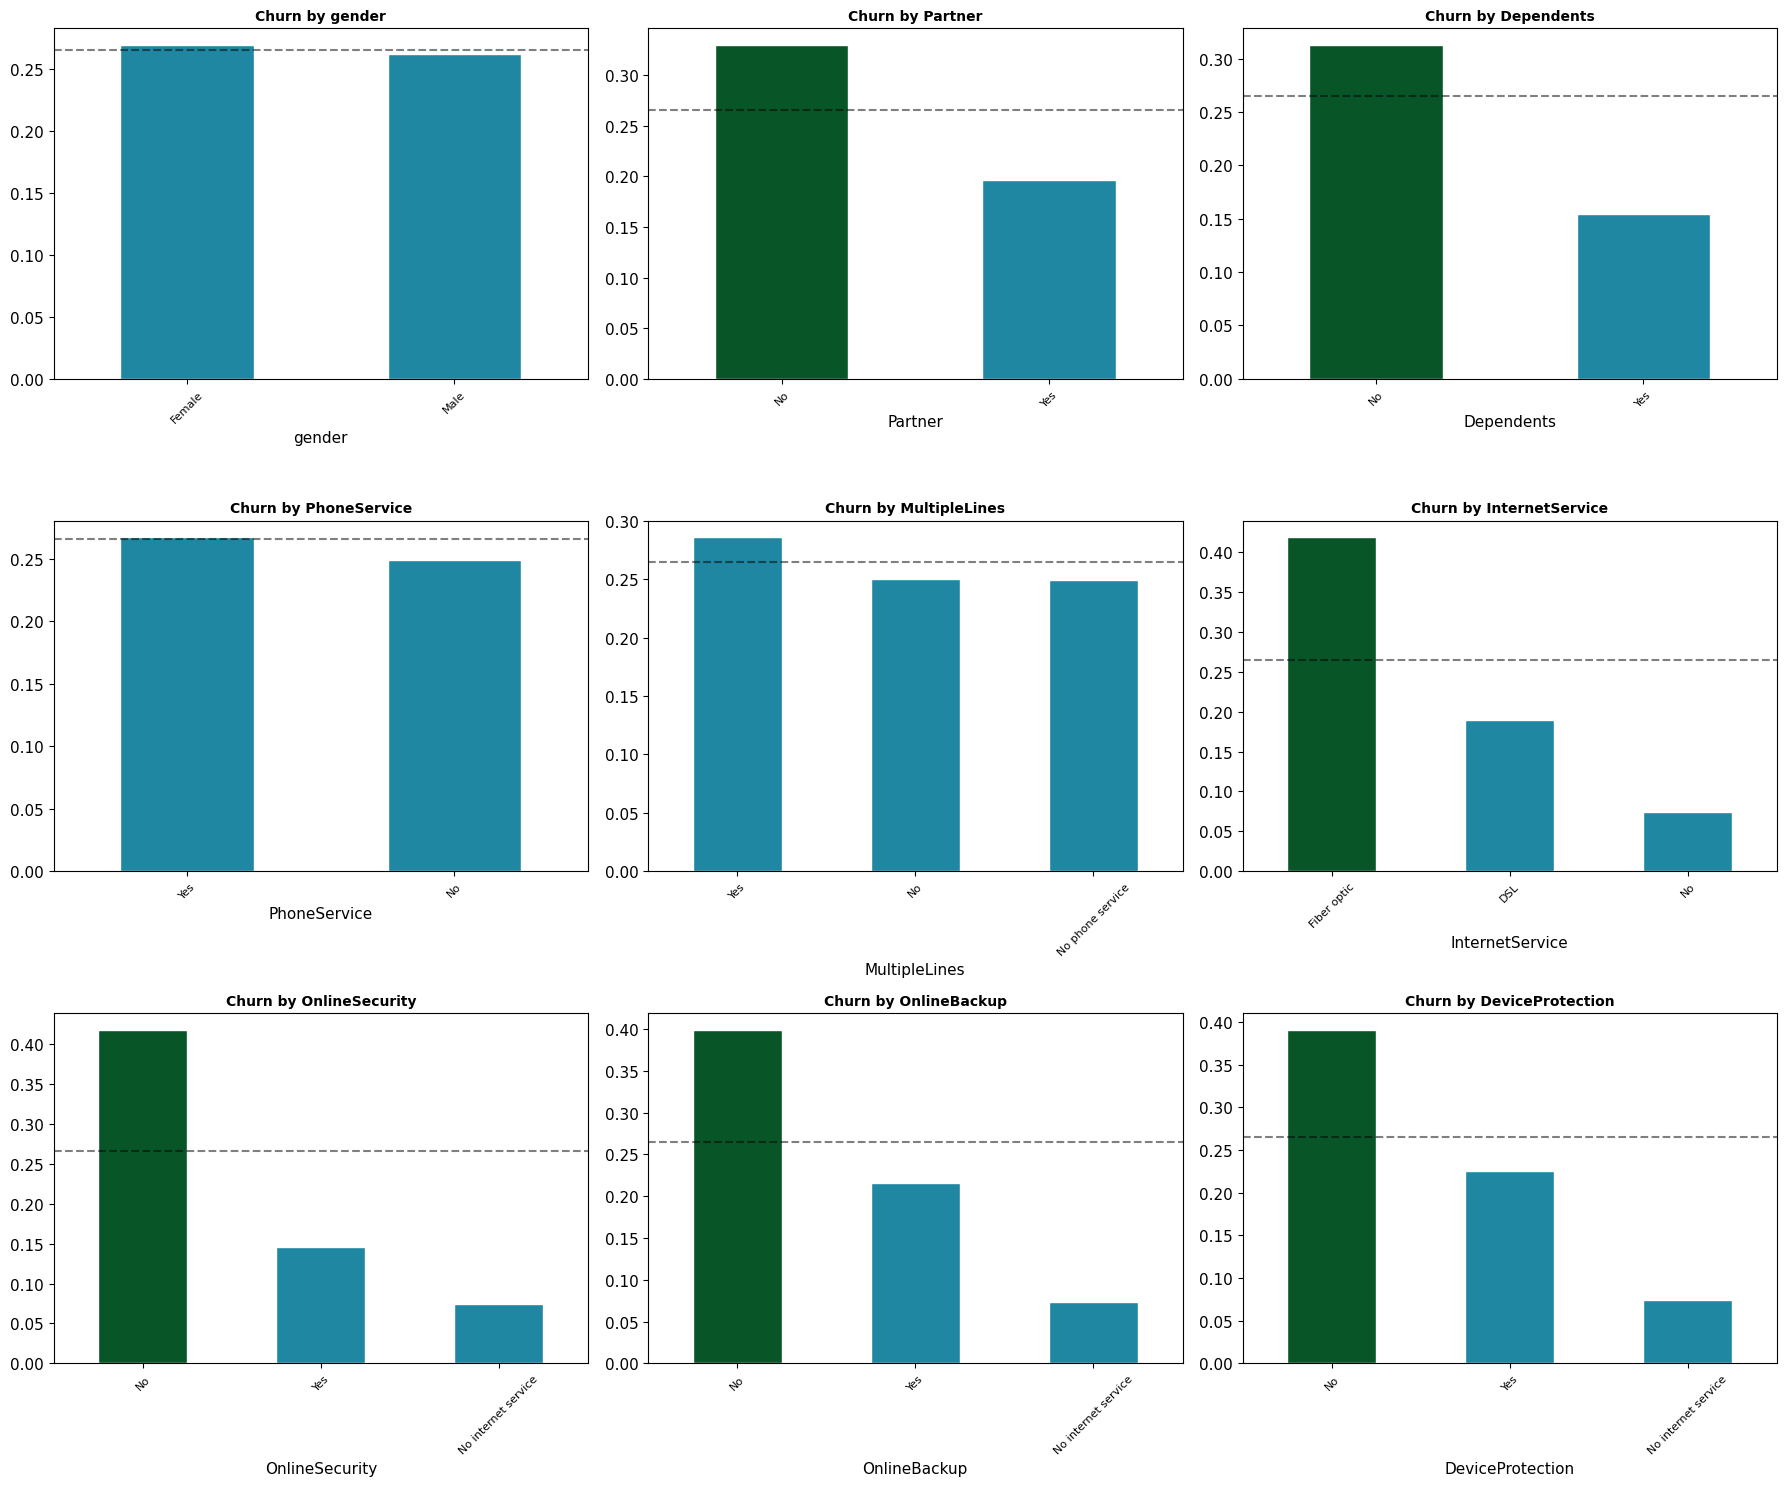

In [13]:
import matplotlib.pyplot as plt
import numpy as np

target_col = 'Churn'
minority_class = 1
churn_pct = df[target_col].mean() * 100 


cat_cols = df.select_dtypes(include=['object']).columns.tolist()
cat_cols = [c for c in cat_cols if c != target_col and df[c].nunique() <= 10]

n_cats = min(len(cat_cols), 9)
if n_cats > 0:
    rows = (n_cats + 2) // 3
    fig, axes = plt.subplots(rows, 3, figsize=(18, 5 * rows))
    axes = np.array(axes).flatten()
    
    for idx, col in enumerate(cat_cols[:n_cats]):
        ax = axes[idx]
        
        cr = df.groupby(col)[target_col].apply(lambda x: (x == minority_class).mean()).sort_values(ascending=False)
        colors = [COLOR_CHURNED if r > churn_pct/100*1.1 else COLOR_RETAINED for r in cr.values]
        cr.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
        ax.set_title(f'Churn by {col}', fontweight='bold', fontsize=10)
        ax.axhline(y=churn_pct/100, color='black', linestyle='--', alpha=0.5)
        ax.tick_params(axis='x', rotation=45, labelsize=8)
    
    
    for idx in range(n_cats, len(axes)):
        axes[idx].set_visible(False)
    plt.tight_layout()
    plt.show()

#### Correlation numerical values

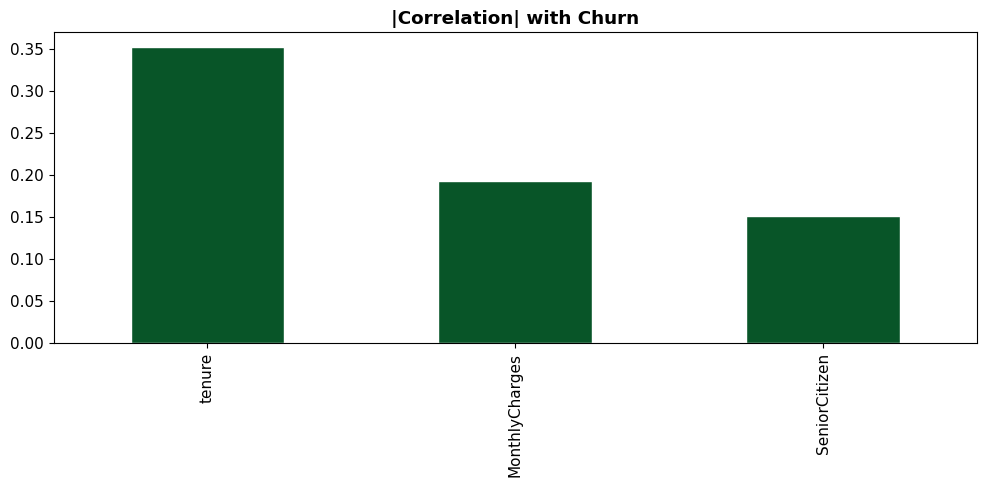

In [14]:
# Correlation

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != target_col]

target_binary = (df[target_col] == minority_class).astype(int)
if num_cols:
    corr = df[num_cols].corrwith(target_binary).abs().sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(10, 5))
    corr.plot(kind='bar', ax=ax, color=[COLOR_CHURNED if c > 0.1 else '#95a5a6' for c in corr.values], edgecolor='white')
    ax.set_title('|Correlation| with Churn', fontweight='bold')
    plt.tight_layout()
    plt.show()

#### Encoding categorical values

In [15]:
df.replace({
    'No phone service': 'No',
    'No internet service': 'No'
}, inplace=True)

In [16]:
binary_cols = ['Partner','Dependents','PhoneService','PaperlessBilling','OnlineSecurity','OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines']

for col in binary_cols:
    df[col] = df[col].map({'Yes':1, 'No':0})

In [17]:
df['gender'] = df['gender'].map({
    'Female': 0,
    'Male': 1
})

In [18]:
df = pd.get_dummies(df, columns=['InternetService'], drop_first=True)

In [19]:
contract_map = {
    'Month-to-month': 0,
    'One year': 1,
    'Two year': 2
}

df['Contract'] = df['Contract'].map(contract_map)

In [20]:
df = pd.get_dummies(df, columns=['PaymentMethod'])

In [21]:
df.head(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,...,1,29.85,29.85,0,False,False,False,False,True,False
1,1,0,0,0,34,1,0,1,0,1,...,0,56.95,1889.5,0,False,False,False,False,False,True
2,1,0,0,0,2,1,0,1,1,0,...,1,53.85,108.15,1,False,False,False,False,False,True
3,1,0,0,0,45,0,0,1,0,1,...,0,42.30,1840.75,0,False,False,True,False,False,False
4,0,0,0,0,2,1,0,0,0,0,...,1,70.70,151.65,1,True,False,False,False,True,False
5,0,0,0,0,8,1,1,0,0,1,...,1,99.65,820.5,1,True,False,False,False,True,False
6,1,0,0,1,22,1,1,0,1,0,...,1,89.10,1949.4,0,True,False,False,True,False,False
7,0,0,0,0,10,0,0,1,0,0,...,0,29.75,301.9,0,False,False,False,False,False,True
8,0,0,1,0,28,1,1,0,0,1,...,1,104.80,3046.05,1,True,False,False,False,True,False
9,1,0,0,1,62,1,0,1,1,0,...,0,56.15,3487.95,0,False,False,True,False,False,False


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   gender                                   7043 non-null   int64  
 1   SeniorCitizen                            7043 non-null   int64  
 2   Partner                                  7043 non-null   int64  
 3   Dependents                               7043 non-null   int64  
 4   tenure                                   7043 non-null   int64  
 5   PhoneService                             7043 non-null   int64  
 6   MultipleLines                            7043 non-null   int64  
 7   OnlineSecurity                           7043 non-null   int64  
 8   OnlineBackup                             7043 non-null   int64  
 9   DeviceProtection                         7043 non-null   int64  
 10  TechSupport                              7043 no

#### Handling object data type

In [23]:
# Convert TotalCharges to numeric, coercing errors to NaN

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

#### Handling missing values

In [24]:
# Fill missing TotalCharges with median

df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

#### Handling bool data type

In [25]:
bool_cols = df.select_dtypes(include=['bool']).columns
df[bool_cols] = df[bool_cols].astype(int)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   gender                                   7043 non-null   int64  
 1   SeniorCitizen                            7043 non-null   int64  
 2   Partner                                  7043 non-null   int64  
 3   Dependents                               7043 non-null   int64  
 4   tenure                                   7043 non-null   int64  
 5   PhoneService                             7043 non-null   int64  
 6   MultipleLines                            7043 non-null   int64  
 7   OnlineSecurity                           7043 non-null   int64  
 8   OnlineBackup                             7043 non-null   int64  
 9   DeviceProtection                         7043 non-null   int64  
 10  TechSupport                              7043 no

In [27]:
df.describe()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,...,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.504756,0.162147,0.483033,0.299588,32.371149,0.903166,0.421837,0.286668,0.344881,0.343888,...,0.592219,64.761692,2281.916928,0.265370,0.439585,0.216669,0.219225,0.216101,0.335794,0.228880
std,0.500013,0.368612,0.499748,0.458110,24.559481,0.295752,0.493888,0.452237,0.475363,0.475038,...,0.491457,30.090047,2265.270398,0.441561,0.496372,0.412004,0.413751,0.411613,0.472301,0.420141
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,18.250000,18.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,35.500000,402.225000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,70.350000,1397.475000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,89.850000,3786.600000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,118.750000,8684.800000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


#### Total taget distribution

In [28]:
import plotly.express as px


counts = df['Churn'].value_counts()


counts = counts.reindex([0, 1])

fig = px.pie(
    values=counts.values,
    names=counts.index,
    width=700,
    height=400,
    color_discrete_sequence=["skyblue", "black"],
    title="Churn vs Non-Churn Distribution"
)

fig.show()

#### Feature engineering

In [29]:
df_feat = df.copy()

#Number of services
service_cols = [
    'PhoneService','MultipleLines','OnlineSecurity','OnlineBackup',
    'DeviceProtection','TechSupport','StreamingTV','StreamingMovies'
]

#Count of all services the customer is subscribed to
df_feat['n_services'] = df_feat[service_cols].sum(axis=1)

# Ratio of monthly charges to tenure
df_feat['charge_tenure_ratio'] = df_feat['MonthlyCharges'] / df_feat['tenure'].clip(lower=1)

# How consistent the charges are compared to expected total
df_feat['charge_consistency'] = df_feat['TotalCharges'] / (df_feat['MonthlyCharges'] * df_feat['tenure'].clip(lower=1))

# Flag for new users (tenure <= 6 months)
df_feat['is_new_user'] = (df_feat['tenure'] <= 6).astype(int)

# Flag for long-term users (tenure >= 48 months)
df_feat['is_long_term'] = (df_feat['tenure'] >= 48).astype(int)

# Average monthly charges (TotalCharges / tenure)
df_feat['AvgCharges'] = df_feat['TotalCharges'] / df_feat['tenure'].clip(lower=1)

# Flag for customers with more than 24 months tenure
df_feat['LongTermCustomer'] = (df_feat['tenure'] > 24).astype(int)



#### Treat skeness

In [30]:
# Log-transformed tenure to reduce skewness
df_feat['tenure_log'] = np.log1p(df_feat['tenure'])

# Log-transform MonthlyCharges to reduce skew
df_feat['MonthlyCharges_log'] = np.log1p(df_feat['MonthlyCharges'])

# Log-transform TotalCharges to reduce skew
df_feat['TotalCharges_log'] = np.log1p(df_feat['TotalCharges'])



In [31]:
# List of newly created features
new_features = [c for c in df_feat.columns if c not in df.columns]
print("Engineered features:", new_features)


Engineered features: ['n_services', 'charge_tenure_ratio', 'charge_consistency', 'is_new_user', 'is_long_term', 'AvgCharges', 'LongTermCustomer', 'tenure_log', 'MonthlyCharges_log', 'TotalCharges_log']


#### feature importance analysis using Cohen’s d

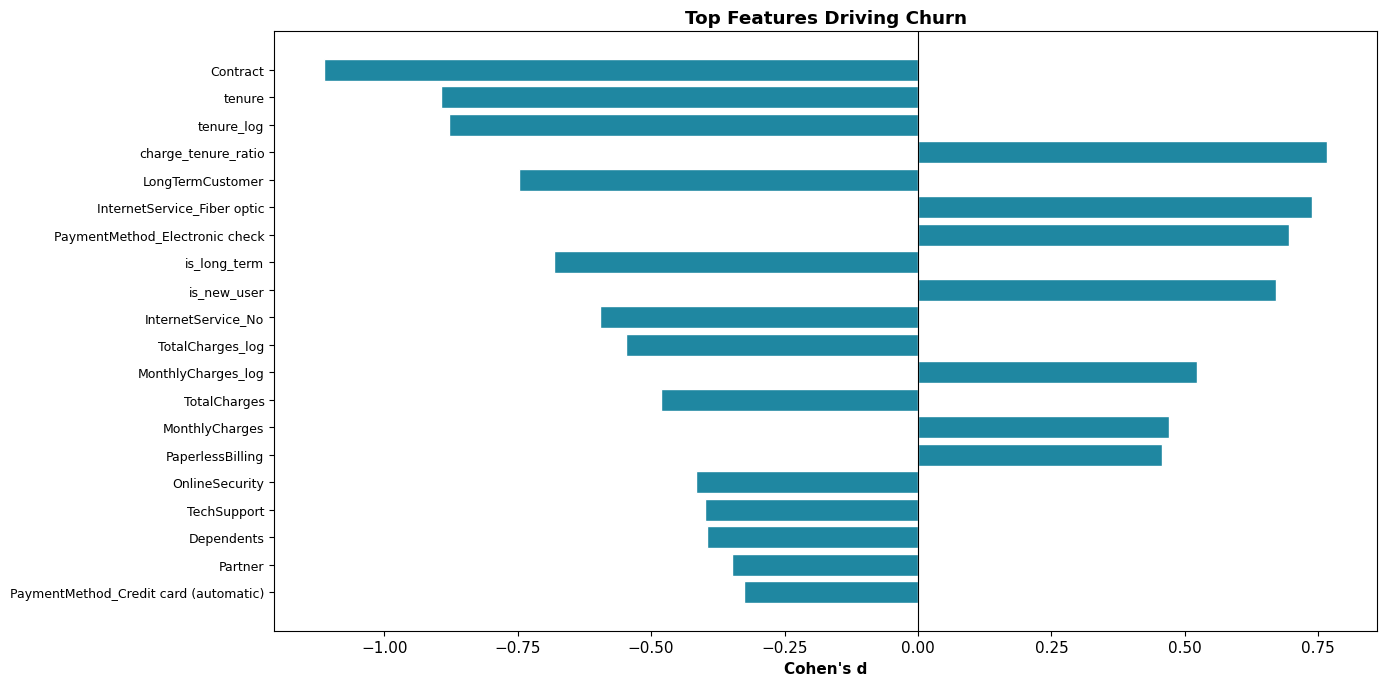

Top disengagement drivers:
  Contract                       d=-1.112
  tenure                         d=-0.893
  tenure_log                     d=-0.879
  charge_tenure_ratio            d=+0.766
  LongTermCustomer               d=-0.747
  InternetService_Fiber optic    d=+0.739
  PaymentMethod_Electronic check d=+0.695
  is_long_term                   d=-0.682


In [32]:
import numpy as np
import matplotlib.pyplot as plt

COLOR_CHURNED = '#1F87A1'
COLOR_RETAINED = '#085528'

# Target and features
target_col = 'Churn'
feature_cols = [c for c in df_feat.columns if c != target_col]

# Data arrays
X = df_feat[feature_cols].values
y = df_feat[target_col].values

# Cohen's d calculation
cohens_d = {}
for i, col in enumerate(feature_cols):
    ok = X[y==0, i]  # retained
    ch = X[y==1, i]  # churned
    ps = np.sqrt((ok.std()**2 + ch.std()**2)/2)   
    cohens_d[col] = (ch.mean() - ok.mean()) / ps if ps > 0 else 0

# Sort by absolute effect
sorted_effects = sorted(cohens_d.items(), key=lambda x: abs(x[1]), reverse=True)

# Plot top 20 features
fig, ax = plt.subplots(figsize=(14, max(6, min(20, len(sorted_effects))*0.35)))
feats = [x[0] for x in sorted_effects[:20]]
vals = [x[1] for x in sorted_effects[:20]]
colors = [COLOR_CHURNED if abs(d)>0.3 else COLOR_RETAINED if abs(d)>0.15 else '#bdc3c7' for d in vals]

ax.barh(range(len(feats)), vals, color=colors, edgecolor='white')
ax.set_yticks(range(len(feats)))
ax.set_yticklabels(feats, fontsize=9)
ax.set_xlabel("Cohen's d", fontweight='bold')
ax.set_title("Top Features Driving Churn", fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Print top 8 features
print("Top disengagement drivers:")
for f, d in sorted_effects[:8]:
    print(f"  {f:30s} d={d:+.3f}")

In [33]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,...,1,29.85,29.85,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,1,0,1,...,0,56.95,1889.50,0,0,0,0,0,0,1
2,1,0,0,0,2,1,0,1,1,0,...,1,53.85,108.15,1,0,0,0,0,0,1
3,1,0,0,0,45,0,0,1,0,1,...,0,42.30,1840.75,0,0,0,1,0,0,0
4,0,0,0,0,2,1,0,0,0,0,...,1,70.70,151.65,1,1,0,0,0,1,0


In [34]:
df_feat.head(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,n_services,charge_tenure_ratio,charge_consistency,is_new_user,is_long_term,AvgCharges,LongTermCustomer,tenure_log,MonthlyCharges_log,TotalCharges_log
0,0,0,1,0,1,0,0,0,1,0,...,1,29.850000,1.000000,1,0,29.850000,0,0.693147,3.429137,3.429137
1,1,0,0,0,34,1,0,1,0,1,...,3,1.675000,0.975830,0,0,55.573529,1,3.555348,4.059581,7.544597
2,1,0,0,0,2,1,0,1,1,0,...,3,26.925000,1.004178,1,0,54.075000,0,1.098612,4.004602,4.692723
3,1,0,0,0,45,0,0,1,0,1,...,3,0.940000,0.967034,0,0,40.905556,1,3.828641,3.768153,7.518471
4,0,0,0,0,2,1,0,0,0,0,...,1,35.350000,1.072489,1,0,75.825000,0,1.098612,4.272491,5.028148
5,0,0,0,0,8,1,1,0,0,1,...,5,12.456250,1.029227,0,0,102.562500,0,2.197225,4.611649,6.711132
6,1,0,0,1,22,1,1,0,1,0,...,4,4.050000,0.994490,0,0,88.609091,0,3.135494,4.500920,7.575790
7,0,0,0,0,10,0,0,1,0,0,...,1,2.975000,1.014790,0,0,30.190000,0,2.397895,3.425890,5.713403
8,0,0,1,0,28,1,1,0,0,1,...,6,3.742857,1.038049,0,0,108.787500,1,3.367296,4.661551,8.021929
9,1,0,0,1,62,1,0,1,1,0,...,3,0.905645,1.001910,0,1,56.257258,1,4.143135,4.045679,8.157356


#### Handle duplication after encoding

In [35]:
df.duplicated().any()

True

#### Count duplicates

In [36]:
duplicate_count = df_feat.duplicated().sum()
print(duplicate_count)

22


#### Drop duplicates

In [37]:
drop_duplicates = df_feat.drop_duplicates()
print(drop_duplicates.shape)

(7021, 34)


#### Save cleaned dataset

In [38]:
object_key_processed = os.getenv("OBJECT_KEY_PROCESSED")

# Convert DataFrame to CSV in memory
csv_buffer = StringIO()
df_feat.to_csv(csv_buffer, index=False)

# Upload to S3
s3.put_object(
    Bucket=bucket_name,
    Key=object_key_processed,
    Body=csv_buffer.getvalue()
)

print(f"Processed CSV uploaded to s3://{bucket_name}/{object_key_processed}")

Processed CSV uploaded to s3://customer-churn-prediction-project/processed/Processed-Telco-Customer-Churn.csv


In [39]:
# from pathlib import Path

# BASE_DIR = Path().resolve()
# PROJECT_DIR = BASE_DIR.parent
# processed_file_path = PROJECT_DIR / "data" / "Processed-Telco-Customer-Churn.csv"
# df_feat.to_csv(processed_file_path, index=False)